# Medallion Architecture on Yeedu — Retail & E-commerce

## Step 0 · Generate the source estate, land **bronze**

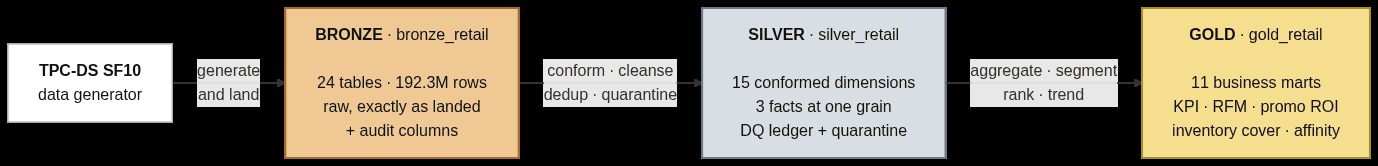

A retail group runs three sales channels — **physical stores**, a **printed catalogue**
and a **web storefront** — each on its own operational system, each with its own
column names, its own idea of what a customer record looks like, and its own
overnight extract. This notebook simulates the nightly landing of that estate.

The source data is **TPC-DS at scale factor 10**, generated by DuckDB: a genuine
retail star schema of 24 tables and **192.3 million rows**, not a toy dataset.

### The one rule of a bronze layer

> Bronze stores what arrived, exactly as it arrived. Nothing is cleaned, deduplicated
> or corrected here.

That is not laziness — it is the point. If a column is corrupt upstream, bronze is the
only place you can prove it was corrupt on arrival rather than broken by your pipeline.
So this notebook deliberately lands data with **duplicate keys, missing dates,
inconsistent country spellings and lower-case state codes still in it**. Silver deals
with those in step 1, and records what it found.

What *is* added is an **audit trail** — every row is stamped with the source system,
the source file, an ingest timestamp and a batch id. That batch id is threaded through
all three layers, and the verify notebook checks it still matches at the end.


In [ ]:
# =====================================================================
# MEDALLION / RETAIL  ·  STEP 0 — GENERATE SOURCE DATA & LAND BRONZE
# ---------------------------------------------------------------------
# Simulates the nightly landing of a retail & e-commerce estate into the
# lakehouse. Six "source systems" (POS, catalog ERP, web storefront, CRM/MDM,
# merchandising ERP, reference data) drop 24 extracts; we land every one of
# them into the BRONZE database exactly as received, plus audit columns.
#
# Bronze rule: land it raw. No cleansing, no dedup, no conforming.
# Whatever the source sent — duplicates, blanks, bad casing — bronze keeps.
# =====================================================================
import os
import shutil
import subprocess
import sys
import time
from datetime import datetime

# ---------------------------------------------------------------------
# DEMO CONSOLE — live, readable progress
# ---------------------------------------------------------------------
# Every helper below flushes. Spark steps here take tens of seconds, and
# without an explicit flush a notebook's output can arrive in one burst at the
# very end — which reads as "nothing is happening" to an audience watching.
# Each step also announces itself BEFORE the work starts, so the pause is
# narrated rather than silent, and reports rows plus throughput when it lands.
import builtins as _bi
import functools as _ft
print = _ft.partial(_bi.print, flush=True)

_W = 78


def fmt(n):
    return "{:,}".format(int(n))


def rule(ch="─"):
    print(ch * _W)


def banner(title, subtitle=""):
    print()
    print("╔" + "═" * (_W - 2) + "╗")
    print("║ " + title.ljust(_W - 3) + "║")
    if subtitle:
        print("║ " + subtitle.ljust(_W - 3) + "║")
    print("╚" + "═" * (_W - 2) + "╝")


def section(num, title):
    print()
    print("▸ %s  %s" % (num, title))
    rule()


def working(msg):
    print("   … %s" % msg)


def ok(name, rows, secs, note=""):
    rate = "%12s rows/s" % fmt(rows / secs) if secs > 0.05 else " " * 18
    print("   ✓ %-28s %14s rows %7.1fs %s%s" % (name, fmt(rows), secs, rate, note))


def skipped(name, rows, what="already built"):
    print("   ~ %-28s %14s rows       —   %s" % (name, fmt(rows), what))


def metric(table, rule_name, value):
    print("       · %-20s %-30s %12s" % (table, rule_name, fmt(value)))


def finished(t0, what):
    print()
    rule("═")
    print("  %s COMPLETE in %.1fs" % (what.upper(), time.time() - t0))
    rule("═")


SCALE_FACTOR = 10                      # TPC-DS SF10 ~= 10 GB of raw source data
WORK_DIR     = "/scratch/disk1/medallion"
DUCKDB_FILE  = os.path.join(WORK_DIR, "source_gen.duckdb")
LANDING_DIR  = os.path.join(WORK_DIR, "landing")
DUCKDB_MEM   = "8GB"

BRONZE_DB = "bronze_retail"
SILVER_DB = "silver_retail"
GOLD_DB   = "gold_retail"

BATCH_ID = "batch_" + datetime.utcnow().strftime("%Y%m%d_%H%M%S")

T_RUN = time.time()
banner("BRONZE  ·  GENERATE & LAND",
       "raw retail extracts, landed exactly as the source systems emit them")

# Which "system" each extract arrives from — this is what makes bronze
# look like a real landing zone rather than one monolithic dump.
SOURCE_SYSTEM = {
    "store_sales": "pos_dw", "store_returns": "pos_dw", "store": "pos_dw",
    "catalog_sales": "catalog_erp", "catalog_returns": "catalog_erp",
    "catalog_page": "catalog_erp", "call_center": "catalog_erp",
    "web_sales": "web_storefront", "web_returns": "web_storefront",
    "web_page": "web_storefront", "web_site": "web_storefront",
    "customer": "crm_mdm", "customer_address": "crm_mdm",
    "customer_demographics": "crm_mdm", "household_demographics": "crm_mdm",
    "income_band": "crm_mdm",
    "item": "merch_erp", "promotion": "merch_erp",
    "inventory": "merch_erp", "warehouse": "merch_erp",
    "date_dim": "ref_data", "time_dim": "ref_data",
    "ship_mode": "ref_data", "reason": "ref_data",
}

os.makedirs(WORK_DIR, exist_ok=True)
print("batch id        :", BATCH_ID)
print("scale factor    :", SCALE_FACTOR)
print("work dir        :", WORK_DIR)
print()
print(subprocess.run(["df", "-h", "/scratch/disk1"], capture_output=True, text=True).stdout)
print(subprocess.run(["free", "-g"], capture_output=True, text=True).stdout)


### 0.1 · Generate the source estate

DuckDB ships a TPC-DS generator, so the "source systems" are produced locally rather
than downloaded. `SCALE_FACTOR` is the single dial for the whole demo — at **SF=10**
this produces roughly 192M rows across 24 tables in about two minutes.


In [ ]:
# ---------------------------------------------------------------------
# 0.1  Generate the source estate with DuckDB's TPC-DS generator
# ---------------------------------------------------------------------
section("0.1", "GENERATE THE SOURCE ESTATE (TPC-DS SF%d)" % SCALE_FACTOR)
working("installing duckdb on the driver …")
subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "duckdb"], check=True)
import duckdb

# start clean so the notebook is safely re-runnable
shutil.rmtree(WORK_DIR, ignore_errors=True)
os.makedirs(LANDING_DIR, exist_ok=True)

con = duckdb.connect(database=DUCKDB_FILE)
con.execute(f"SET temp_directory='{WORK_DIR}'")     # spill to disk, not RAM
con.execute(f"SET memory_limit='{DUCKDB_MEM}'")
con.execute("SET preserve_insertion_order=false")
con.execute("INSTALL tpcds; LOAD tpcds;")

working("running dsdgen at scale factor %d — this is the long one, "
        "roughly a minute per GB …" % SCALE_FACTOR)
t0 = time.time()
con.execute(f"CALL dsdgen(sf={SCALE_FACTOR})")
gen_s = time.time() - t0

tables = [r[0] for r in con.execute(
    "SELECT table_name FROM duckdb_tables() ORDER BY table_name").fetchall()]
working("counting rows in %d generated extracts …" % len(tables))
counts = {t: con.execute(f"SELECT count(*) FROM {t}").fetchone()[0] for t in tables}

ok("dsdgen", sum(counts.values()), gen_s, "  (%d extracts, %.1f min)" % (len(tables), gen_s / 60))
print()
print("   %-26s %14s   %s" % ("EXTRACT", "ROWS", "SOURCE SYSTEM"))
rule("·")
for t in sorted(counts, key=lambda x: -counts[x]):
    print("   %-26s %14s   %s" % (t, fmt(counts[t]), SOURCE_SYSTEM.get(t, "?")))
rule("·")
print("   %-26s %14s" % ("TOTAL", fmt(sum(counts.values()))))


### 0.2 · Drop the extracts into the landing zone

Each table is written out as Parquet, exactly as a nightly extract job would leave it.
This is the boundary between "someone else's system" and "our lakehouse".


In [ ]:
# ---------------------------------------------------------------------
# 0.2  Drop the extracts into the landing zone as Parquet files
# ---------------------------------------------------------------------
section("0.2", "DROP THE EXTRACTS INTO THE LANDING ZONE")
t0 = time.time()
for i, t in enumerate(tables, 1):
    working("[%2d/%d] writing %s.parquet …" % (i, len(tables), t))
    con.execute(
        f"COPY {t} TO '{LANDING_DIR}/{t}.parquet' (FORMAT PARQUET, COMPRESSION ZSTD)")
exp_s = time.time() - t0
con.close()

sizes = {f: os.path.getsize(os.path.join(LANDING_DIR, f)) for f in os.listdir(LANDING_DIR)}
total_bytes = sum(sizes.values())
ok("landing zone", sum(counts.values()), exp_s,
   "  (%d files, %.2f GB zstd on disk)" % (len(sizes), total_bytes / 1e9))
print()
for f in sorted(sizes, key=lambda f: -sizes[f])[:10]:
    print("  %-32s %9.1f MB" % (f, sizes[f] / 1e6))


### 0.3 · Spark session and the bronze database

The cluster already has Hive credentials configured, so `saveAsTable` writes
Hive-managed Parquet with no extra setup. **Note the shuffle-partition setting** —
on this 8-core cluster the Spark default of 200 is the single biggest performance
trap, turning a two-second write into twenty seconds of pure task scheduling.


In [ ]:
# ---------------------------------------------------------------------
# 0.3  Spark session + bronze database
# ---------------------------------------------------------------------
from pyspark.sql import SparkSession, functions as F

spark = SparkSession.builder.appName("medallion-bronze").getOrCreate()
spark.conf.set("spark.sql.shuffle.partitions", "64")
spark.conf.set("spark.sql.adaptive.enabled", "true")
spark.conf.set("spark.sql.adaptive.coalescePartitions.enabled", "true")
spark.conf.set("spark.sql.sources.partitionOverwriteMode", "dynamic")
spark.conf.set("spark.sql.parquet.compression.codec", "snappy")

spark.sql(f"CREATE DATABASE IF NOT EXISTS {BRONZE_DB} "
          f"COMMENT 'Raw landing zone — retail & e-commerce source extracts, as received'")
section("0.3", "SPARK SESSION AND BRONZE DATABASE")
print("bronze database ready:", BRONZE_DB)
print("driver memory       :", spark.sparkContext.getConf().get("spark.driver.memory", "<cluster default>"))
print("warehouse root      :", spark.conf.get("spark.sql.warehouse.dir", "<unset>"))


### 0.4 · Source-system realism

Six named source systems, so the lineage columns mean something in a demo: a viewer
can point at any bronze row and say *which system it came from*. This is also where
the deliberate defects are introduced — the ones silver will catch and report.


In [ ]:
# ---------------------------------------------------------------------
# 0.4  Source-system realism
#
# Real extracts are not clean. CDC replays send the same row twice, CRM
# free-text fields carry stray casing and whitespace, and ERP feeds ship
# the occasional null price or negative quantity from a correction entry.
# We reproduce exactly those defects here so the SILVER layer has genuine
# work to do — and so the data-quality metrics later are real numbers.
# ---------------------------------------------------------------------
section("0.4", "SOURCE-SYSTEM REALISM")
FACT_KEYS = {
    "store_sales":    ("ss_item_sk", "ss_ticket_number", "ss_quantity", "ss_net_paid"),
    "catalog_sales":  ("cs_item_sk", "cs_order_number",  "cs_quantity", "cs_net_paid"),
    "web_sales":      ("ws_item_sk", "ws_order_number",  "ws_quantity", "ws_net_paid"),
    "store_returns":  ("sr_item_sk", "sr_ticket_number", "sr_return_quantity", "sr_net_loss"),
    "catalog_returns":("cr_item_sk", "cr_order_number",  "cr_return_quantity", "cr_net_loss"),
    "web_returns":    ("wr_item_sk", "wr_order_number",  "wr_return_quantity", "wr_net_loss"),
}


def inject_source_defects(name, df):
    """Reproduce the defects a real feed for this table would carry."""
    if name in FACT_KEYS:
        _, _, qty_col, amt_col = FACT_KEYS[name]
        # 0.4% of monetary values arrive null (ERP posting not yet settled)
        df = df.withColumn(amt_col, F.when(F.rand(101) < 0.004, F.lit(None))
                                     .otherwise(F.col(amt_col)))
        # 0.2% negative quantities — manual correction entries keyed as sales
        df = df.withColumn(qty_col, F.when(F.rand(102) < 0.002, -F.abs(F.col(qty_col)))
                                     .otherwise(F.col(qty_col)))
        # 1.5% duplicated rows — CDC replay after a failed batch
        df = df.unionByName(df.sample(False, 0.015, seed=103))
        return df

    if name == "customer":
        df = (df
              .withColumn("c_email_address",
                          F.when(F.rand(201) < 0.03, F.lit(None)).otherwise(F.col("c_email_address")))
              .withColumn("c_first_name",
                          F.when(F.rand(202) < 0.18, F.concat(F.col("c_first_name"), F.lit("   ")))
                           .when(F.rand(203) < 0.18, F.upper(F.col("c_first_name")))
                           .otherwise(F.col("c_first_name")))
              .withColumn("c_last_name",
                          F.when(F.rand(204) < 0.12, F.lower(F.col("c_last_name")))
                           .otherwise(F.col("c_last_name"))))
        return df.unionByName(df.sample(False, 0.02, seed=205))   # MDM re-send

    if name == "customer_address":
        df = (df
              .withColumn("ca_state",
                          F.when(F.rand(301) < 0.25, F.lower(F.col("ca_state"))).otherwise(F.col("ca_state")))
              .withColumn("ca_zip",
                          F.when(F.rand(302) < 0.02, F.lit(None)).otherwise(F.col("ca_zip")))
              .withColumn("ca_country",
                          F.when(F.rand(303) < 0.20, F.lit("USA"))
                           .when(F.rand(304) < 0.10, F.lit("us"))
                           .otherwise(F.col("ca_country"))))
        return df.unionByName(df.sample(False, 0.02, seed=305))

    if name == "item":
        df = (df
              .withColumn("i_current_price",
                          F.when(F.rand(401) < 0.01, F.lit(None)).otherwise(F.col("i_current_price")))
              .withColumn("i_category",
                          F.when(F.rand(402) < 0.15, F.concat(F.lit(" "), F.col("i_category")))
                           .otherwise(F.col("i_category"))))
        return df.unionByName(df.sample(False, 0.015, seed=403))

    if name == "store":
        return df.withColumn("s_store_name",
                             F.when(F.rand(501) < 0.3, F.concat(F.col("s_store_name"), F.lit(" ")))
                              .otherwise(F.col("s_store_name")))
    return df

print("defect profiles defined for", len(FACT_KEYS) + 4, "extracts")


### 0.5 · Land every extract into bronze, with its audit trail

The landing loop is uniform: read the extract, stamp it with
`_source_system`, `_source_file`, `_ingest_ts` and `_batch_id`, write it to Hive.
No transformation of any kind.


In [ ]:
# ---------------------------------------------------------------------
# 0.5  Land every extract into BRONZE with its audit trail
# ---------------------------------------------------------------------
def target_files(n_rows):
    """Keep bronze parquet files in a sane 100-250 MB range."""
    return max(1, min(24, n_rows // 4_000_000 + 1))


section("0.5", "LAND EVERY EXTRACT INTO BRONZE WITH ITS AUDIT TRAIL")
ingest_started = time.time()
landed = {}
for i, t in enumerate(sorted(tables), 1):
    t0 = time.time()
    src_file = f"{t}.parquet"
    working("[%2d/%d] landing %s …" % (i, len(tables), t))
    df = spark.read.parquet(f"file://{LANDING_DIR}/{src_file}")
    df = inject_source_defects(t, df)

    df = (df
          .withColumn("_source_system", F.lit(SOURCE_SYSTEM.get(t, "unknown")))
          .withColumn("_source_file",   F.lit(src_file))
          .withColumn("_batch_id",      F.lit(BATCH_ID))
          .withColumn("_ingest_ts",     F.current_timestamp()))

    n = counts[t]
    df = df.repartition(target_files(n))
    (df.write.mode("overwrite").format("parquet")
       .option("compression", "snappy")
       .saveAsTable(f"{BRONZE_DB}.{t}"))

    landed[t] = spark.table(f"{BRONZE_DB}.{t}").count()
    ok(t, landed[t], time.time() - t0,
       "  +%s injected" % fmt(landed[t] - n) if landed[t] != n else "")

rule()
print("   BRONZE LANDED: %d tables, %s rows in %.1f min" % (
    len(landed), fmt(sum(landed.values())), (time.time() - ingest_started) / 60))


### 0.6 · Prove it — what bronze holds, and what is wrong with it

The payoff cell. It prints the full bronze inventory **and** the defects that are
sitting in it right now. Keep this output on screen: step 1 reports the same numbers
from the other side, as things it fixed.


In [ ]:
# ---------------------------------------------------------------------
# 0.6  Prove it: what bronze holds, and what is wrong with it
# ---------------------------------------------------------------------
spark.sql(f"USE {BRONZE_DB}")
section("0.6", "BRONZE TABLES")
spark.sql(f"SHOW TABLES IN {BRONZE_DB}").show(30, False)

section("0.7", "DEFECTS BRONZE IS CARRYING — SILVER\'S TO-DO LIST")
spark.sql(f"""
  SELECT 'customer'         AS tbl, 'duplicate customer keys'  AS defect, count(*) AS n
  FROM (SELECT c_customer_sk FROM {BRONZE_DB}.customer GROUP BY c_customer_sk HAVING count(*) > 1)
  UNION ALL
  SELECT 'customer', 'missing email',      count(*) FROM {BRONZE_DB}.customer WHERE c_email_address IS NULL
  UNION ALL
  SELECT 'customer', 'untrimmed first name', count(*) FROM {BRONZE_DB}.customer WHERE c_first_name <> trim(c_first_name)
  UNION ALL
  SELECT 'customer_address', 'country spelling variants', count(DISTINCT ca_country) FROM {BRONZE_DB}.customer_address
  UNION ALL
  SELECT 'customer_address', 'lower-case state codes', count(*) FROM {BRONZE_DB}.customer_address WHERE ca_state <> upper(ca_state)
  UNION ALL
  SELECT 'customer_address', 'missing zip', count(*) FROM {BRONZE_DB}.customer_address WHERE ca_zip IS NULL
  UNION ALL
  SELECT 'item', 'missing price', count(*) FROM {BRONZE_DB}.item WHERE i_current_price IS NULL
  UNION ALL
  SELECT 'store_sales', 'null net_paid',   count(*) FROM {BRONZE_DB}.store_sales WHERE ss_net_paid IS NULL
  UNION ALL
  SELECT 'store_sales', 'negative quantity', count(*) FROM {BRONZE_DB}.store_sales WHERE ss_quantity < 0
  UNION ALL
  SELECT 'store_sales', 'duplicate (item,ticket)', count(*) FROM
    (SELECT ss_item_sk, ss_ticket_number FROM {BRONZE_DB}.store_sales
      GROUP BY ss_item_sk, ss_ticket_number HAVING count(*) > 1)
  ORDER BY tbl, defect
""").show(30, False)

section("0.8", "AUDIT TRAIL SAMPLE")
spark.sql(f"""SELECT _source_system, _batch_id, count(*) AS rows, count(DISTINCT _source_file) AS files
              FROM (SELECT _source_system,_batch_id,_source_file FROM {BRONZE_DB}.store_sales
                    UNION ALL SELECT _source_system,_batch_id,_source_file FROM {BRONZE_DB}.web_sales
                    UNION ALL SELECT _source_system,_batch_id,_source_file FROM {BRONZE_DB}.customer)
              GROUP BY _source_system, _batch_id""").show(10, False)

print("\nlocation:", spark.sql(f"DESCRIBE FORMATTED {BRONZE_DB}.store_sales")
      .filter("col_name = 'Location'").collect()[0]["data_type"])
finished(T_RUN, "BRONZE")
print("   batch %s — next: 01_silver_conform_and_cleanse" % BATCH_ID)
